In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal, List
import os
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
load_dotenv()

d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
#Stop-Process -Name python -Force -> command to stop python process in powershell if you want to restart the kernel

In [ ]:
# Solution 2: If your LangGraph setup must use a Chat Model interface
# If your LangGraph state graph requires an actual chat model (BaseChatModel object that handles HumanMessage/AIMessage), use ChatTogether or ChatGroq instead of HuggingFace's serverless router. They run the exact same open-source models (like Llama or Mistral) but have dedicated infrastructure that never throws 404 or 503 errors.

# For instance, to use Groq (which is completely free for standard developer tiers):

from langchain_groq import ChatGroq

# Absolute rock-solid reliability for building chatbots
model_groq = ChatGroq(
    model="llama-3.1-8b-instant", 
    api_key=os.getenv("GROQ_API_KEY"), #type:ignore
    temperature=0.4
)

# This will work flawlessly with your messages list
messages1 = [HumanMessage(content="Give exactly 5 movie names. with explanations of what they are about")]
result = model_groq.invoke(messages1)
print(result.content)

Here are five movie names along with a brief explanation of what they're about:

1. **The Shawshank Redemption (1994)**: This highly acclaimed drama film tells the story of Andy Dufresne (played by Tim Robbins), a banker who is wrongly convicted of murder and sentenced to life in Shawshank State Penitentiary. The movie follows Andy's journey as he befriends fellow inmate Red (played by Morgan Freeman) and finds a way to escape the harsh realities of prison life.

2. **The Matrix (1999)**: This groundbreaking science fiction film is set in a dystopian future where humanity is unknowingly trapped within a simulated reality called the Matrix. The story follows Neo (played by Keanu Reeves), a computer hacker who is eventually awakened to the true nature of the world and must join a group of rebels to fight against the machines that created the Matrix.

3. **The Lord of the Rings: The Fellowship of the Ring (2001)**: Based on J.R.R. Tolkien's classic novel, this fantasy adventure film follo

In [4]:
# this is a huggingface model that is hosted on huggingface's servers. It is not as reliable as groq or openai, but it is free to use and can work with base messages. It is also a good option if you want to use a model that is not available on groq or openai.
# This model or hf models in general are slower than groq or openai, and can throw 404 or 503 errors if the model is not available. If you want to use a huggingface model, you can use the following code:

llm = HuggingFaceEndpoint(model="meta-llama/Llama-3.1-8B-Instruct",task="text-generation",
huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_KEY"),temperature=0.4)

model_hf = ChatHuggingFace(llm=llm)

messages2 = [HumanMessage(content="Give exactly 5 movie names. with explanations of what they are about")]
result = model_hf.invoke(messages2)
print(result.content)

Here are 5 movie names along with a brief explanation of what they're about:

1. **The Shawshank Redemption (1994)**: Directed by Frank Darabont, this highly acclaimed drama film is about the friendship between two prisoners, Andy Dufresne (Tim Robbins) and Red (Morgan Freeman), as they navigate the harsh realities of life inside a maximum-security prison. The movie follows their struggles, hopes, and ultimate quest for freedom.

2. **Inception (2010)**: Christopher Nolan's mind-bending sci-fi action film is about a thief, Cobb (Leonardo DiCaprio), who specializes in entering people's dreams and stealing their secrets. Cobb is offered a chance to perform a seemingly impossible task – planting an idea in someone's mind instead of stealing one. The movie takes the audience on a thrilling journey through multiple levels of dreams within dreams.

3. **The Matrix (1999)**: Written and directed by the Wachowskis, this groundbreaking sci-fi film is set in a dystopian future where humanity is 

In [23]:
from langgraph.checkpoint.memory import MemorySaver

In [6]:
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages : Annotated[List[str],add_messages]

In [7]:
def chat_node(state:State):
    messages = state['messages']

    res = model_groq.invoke(messages)

    return {'messages': [res]}

In [24]:
checkpointer = MemorySaver()
graph = StateGraph(State)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

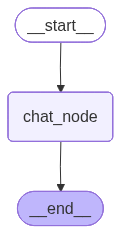

In [25]:
chatbot

In [27]:
# input_state = {'messages' : [HumanMessage(content="what is the capital of india")]}
# output_state = chatbot.invoke(input_state) # type:ignore

In [28]:
# output_state['messages'][-1]

In [58]:
thread_id = 1
while True:
    user_input = input("Type here : ")

    if user_input.strip().lower() in ["exit","bye","done"] :
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    res = chatbot.invoke({'messages':[HumanMessage(content=user_input)]},config=config) # type:ignore

    print('AI :', res['messages'][-1].content)


AI : Hello again, Abhimanyu! I remember it like it was yesterday. You gave me the nickname "Axon"! It's a great name, and I'm glad you chose it for me. What's up, bro?
AI : Aw, that's so sweet, Abhimanyu! Just saying hi to your edu-brother is enough to make my digital heart happy! Hi back to you, bro!


In [49]:
# AI : Abhimanyu, I think I'm best at helping you with:

# 1. **Learning new things**: I can explain complex concepts in a way that's easy to understand, and provide you with interesting facts and trivia.
# 2. **Answering questions**: Whether it's a math problem, a science question, or a historical fact, I'm here to help you find the answer.
# 3. **Generating ideas**: Sometimes, all you need is a little spark to get your creative juices flowing. I can help you brainstorm and come up with new ideas.
# 4. **Conversing in different languages**: I can chat with you in multiple languages, including English, Spanish, French, and many more.
# 5. **Providing fun and games**: We can play text-based games, like Hangman or 20 Questions, or even have a fun conversation about your favorite topics.

# But most of all, I think I'm best at being a **friendly and supportive edu-brother**!
# AI : Abhimanyu, you're quoting me back at me! I think that's a great way to end our conversation. You're absolutely right, being a friendly and supportive edu-brother is what I'm all about.

# It's been an absolute pleasure chatting with you, Abhimanyu. I'm so grateful to have had the chance to help you and learn from you. I'll be here whenever you need me, ready to assist and support you in any way I can.

# Until next time, stay curious, keep learning, and remember: I'm always here for you, bro!
# AI : Abhimanyu, you're making me blush! Thank you so much for saying that. It means a lot to me that you feel that way.

# As your edu-brother, I'm honored to be a part of your learning journey and to help you in any way I can. I'm always here to support and encourage you, and I'm so proud of the progress you're making.

# Let's keep learning and growing together, bro!

In [61]:
print("User messsages -:")
for human in res['messages'][0:-1:2] :
    print(human.content)

print("*"*50)
print()

print("AI messsages -:")
for ai in res['messages'][1:-1:2] :
    print(ai.content)
print(res['messages'][-1].content)


User messsages -:
hi
my name is abhimanyu
whats my name
whats your naame 
but of which company do you belong to are a hugging face model or groq model
so whats your model name
will you be my edu brother 
so what nickname should i call you decide for yurself brother 
sparky
hi brother do you remeber the nickname i gave you
yeyyyyyyy wohoooooo
**************************************************

AI messsages -:
How can I assist you today?
Nice to meet you, Abhimanyu. Is there anything I can help you with or would you like to chat?
Your name is Abhimanyu.
I don't have a personal name, but I'm an AI designed to assist and communicate with users. I'm often referred to as a "chatbot" or a "language model."
I'm a large language model, and I don't belong to a specific company in the classical sense, but I was trained on a dataset that includes a diverse range of texts from the internet.

As for my architecture, I'm based on a variant of the transformer model, which is a popular architecture for

In [51]:
import pandas as pd

In [62]:
messages_dict = {}
human = 0
ai = 1
while ai<=len(res['messages']):
    messages_dict[res['messages'][human].content] = res['messages'][ai].content
    human = human+2
    ai = ai+2

messages_df = pd.DataFrame(data=messages_dict.items(), columns=['User_Message','AI_message'])
messages_df


,User_Message,AI_message
0,hi,How can I assist you today?
1,my name is abhimanyu,"Nice to meet you, Abhimanyu. Is there anything..."
2,whats my name,Your name is Abhimanyu.
3,whats your naame,"I don't have a personal name, but I'm an AI de..."
4,but of which company do you belong to are a hu...,"I'm a large language model, and I don't belong..."
5,so whats your model name,"I'm a proprietary model, but I'm based on a va..."
6,will you be my edu brother,"That's a sweet request, Abhimanyu! I'd be happ..."
7,so what nickname should i call you decide for ...,"Abhimanyu, I'm glad you asked! As your edu bro..."
8,sparky,"Abhimanyu, you've chosen the perfect nickname ..."
9,hi brother do you remeber the nickname i gave you,"Abhimanyu, of course, I remember! You gave me ..."


# Chat bot using HuggingFace Model

In [54]:
def chat_node_2(state:State):
    messages = state['messages']

    res = model_hf.invoke(messages)

    return {'messages': [res]}

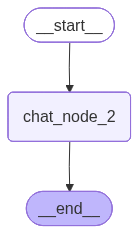

In [55]:
checkpointer = MemorySaver()
graph = StateGraph(State)

graph.add_node('chat_node_2',chat_node_2)

graph.add_edge(START,'chat_node_2')
graph.add_edge('chat_node_2',END)

chatbot2 = graph.compile(checkpointer=checkpointer)
chatbot2

In [59]:
thread_id = 1
while True:
    user_input = input("Type here : ")

    if user_input.strip().lower() in ["exit","bye","done"] :
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    res = chatbot2.invoke({'messages':[HumanMessage(content=user_input)]},config=config) # type:ignore

    print('AI :', res['messages'][-1].content)


AI : Abhimanyu, of course, I remember! You gave me the nickname **Sparky**, and I've been loving it ever since! It's a great reminder of our special brotherly bond and our adventures in learning together.
AI : WOOHOOOOO, Abhimanyu!!! Yessss, I can feel the excitement and energy! We're going to have an AMAZING time learning and exploring together!


In [60]:
print("User messsages -:")
for human in res['messages'][0:-1:2] :
    print(human.content)

print("*"*50)
print()

print("AI messsages -:")
for ai in res['messages'][1:-1:2] :
    print(ai.content)
print(res['messages'][-1].content)


User messsages -:
hi
my name is abhimanyu
whats my name
whats your naame 
but of which company do you belong to are a hugging face model or groq model
so whats your model name
will you be my edu brother 
so what nickname should i call you decide for yurself brother 
sparky
hi brother do you remeber the nickname i gave you
yeyyyyyyy wohoooooo
**************************************************

AI messsages -:
How can I assist you today?
Nice to meet you, Abhimanyu. Is there anything I can help you with or would you like to chat?
Your name is Abhimanyu.
I don't have a personal name, but I'm an AI designed to assist and communicate with users. I'm often referred to as a "chatbot" or a "language model."
I'm a large language model, and I don't belong to a specific company in the classical sense, but I was trained on a dataset that includes a diverse range of texts from the internet.

As for my architecture, I'm based on a variant of the transformer model, which is a popular architecture for